<a href="https://colab.research.google.com/github/Gilf4/lab3_ml/blob/main/lab3_ex2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Смирнов Егор 23-ИИ Лабораторная работа: 3.  
Вариант:9 (ResNet152V2).  
Вторая часть лабораторной. Обучения собственной CNN.  

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns


In [2]:
dataset_hh, info_hh = tfds.load(
    'horses_or_humans',
    split='train + test',
    as_supervised=True,
    with_info=True
)

dataset_cd, info_cd = tfds.load(
    'cats_vs_dogs',
    split=f'train[:{len(dataset_hh)}]',
    as_supervised=True,
    with_info=True
)

In [3]:
print(f"Horses vs Humans: {len(dataset_hh)}")
print(f"Cats vs Dogs: {len(dataset_cd)}")

Horses vs Humans: 1283
Cats vs Dogs: 1283


In [4]:
IMG_SIZE = 224

def process_hh(image, label):
    # Лошади/Люди: 0 и 1
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

def process_cd(image, label):
    # Кошки/Собаки: 2 и 3
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label + 2

dataset_hh = dataset_hh.map(process_hh)
dataset_cd = dataset_cd.map(process_cd)

In [5]:
dataset = dataset_hh.concatenate(dataset_cd)
len(dataset)

2566

In [6]:
all_images, all_labels = [], []
for image, label in dataset:
    all_images.append(image.numpy())
    all_labels.append(label.numpy())

all_images = np.array(all_images)
all_labels = np.array(all_labels)


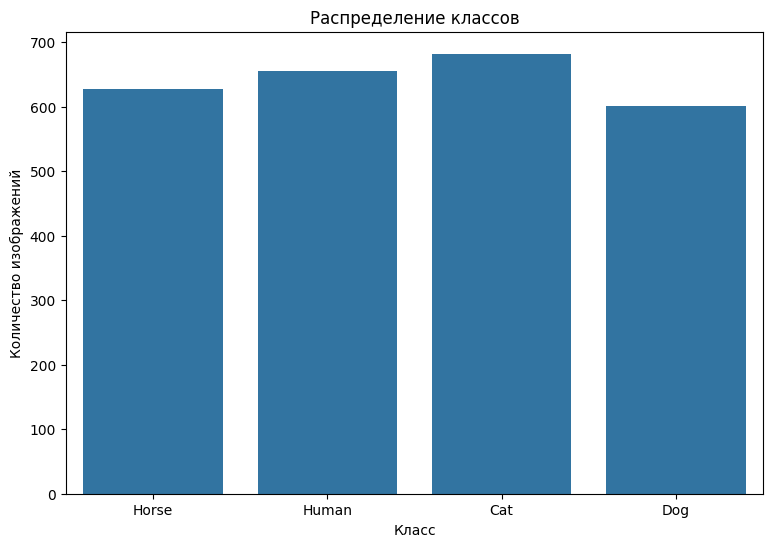

In [7]:
class_map = {0: 'Horse', 1: 'Human', 2: 'Cat', 3: 'Dog'}
df = pd.DataFrame({'Label': all_labels})

plt.figure(figsize=(9, 6))
sns.countplot(data=df, x='Label')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Horse', 'Human', 'Cat', 'Dog'])
plt.title("Распределение классов")
plt.ylabel("Количество изображений")
plt.xlabel("Класс")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    all_images, all_labels,
    test_size=0.15,
    random_state=42,
    stratify=all_labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=42,
    stratify=y_temp
)

print(f"Train: {X_train.shape[0]}") # 70%
print(f"Val: {X_val.shape[0]}")     # 15%
print(f"Test: {X_test.shape[0]}")   # 15%

Train: 1797
Val: 384
Test: 385


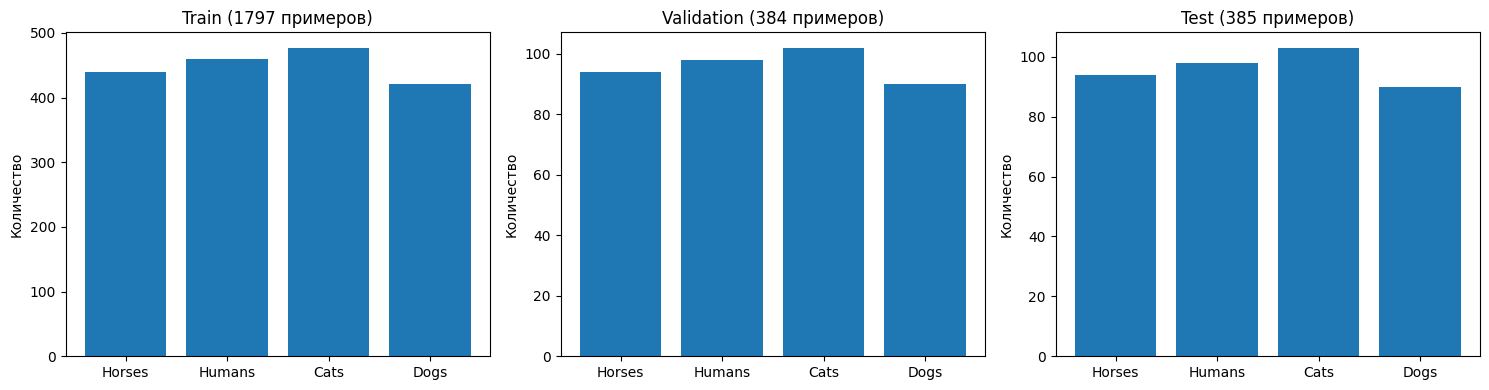

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
datasets = [y_train, y_val, y_test]
titles = ['Train', 'Validation', 'Test']
class_names = ['Horses', 'Humans', 'Cats', 'Dogs']

for i, (y_data, title) in enumerate(zip(datasets, titles)):
    unique, counts = np.unique(y_data, return_counts=True)
    axes[i].bar([class_names[cls] for cls in unique], counts)
    axes[i].set_title(f'{title} ({len(y_data)} примеров)')
    axes[i].set_ylabel('Количество')

plt.tight_layout()
plt.show()

In [10]:
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (1797, 224, 224, 3), y_train: (1797,)
X_val: (384, 224, 224, 3), y_val: (384,)
X_test: (385, 224, 224, 3), y_test: (385,)


In [11]:
from tensorflow.keras import layers, models

input_shape=(224, 224, 3)
num_classes=4

model = models.Sequential([
    # Свертка
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),

    # Свертка
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Свертка
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Свертка
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # FC
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265,348 (73.49 MB)

 Trainable params: 19,265,348 (73.49 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    )
]


In [17]:
history = model.fit(
    x=X_train,
    y=y_train,
    batch_size=32,
    epochs=10,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 266s 5s/step - accuracy: 0.6677 - loss: 0.7675 - val_accuracy: 0.6562 - val_loss: 0.7543
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 256s 5s/step - accuracy: 0.7042 - loss: 0.6603 - val_accuracy: 0.7188 - val_loss: 0.5988
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 271s 5s/step - accuracy: 0.7319 - loss: 0.5531 - val_accuracy: 0.7734 - val_loss: 0.5511
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 320s 5s/step - accuracy: 0.7559 - loss: 0.5316 - val_accuracy: 0.7786 - val_loss: 0.4557
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 270s 5s/step - accuracy: 0.8115 - loss: 0.4169 - val_accuracy: 0.7812 - val_loss: 0.4846
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 261s 5s/step - accuracy: 0.8467 - loss: 0.3255 - val_accuracy: 0.7760 - val_loss: 0.4928
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 263s 5s/step - accuracy: 0.8755 - loss: 0.2754 - val_accuracy: 0.7656 - val_loss: 0.4967
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 266s 5s/step - accuracy: 0.8760 - loss: 0.2930 - val_accuracy: 0.7943 - v

In [19]:
model.load_weights('best_model.keras')

y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step


In [20]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

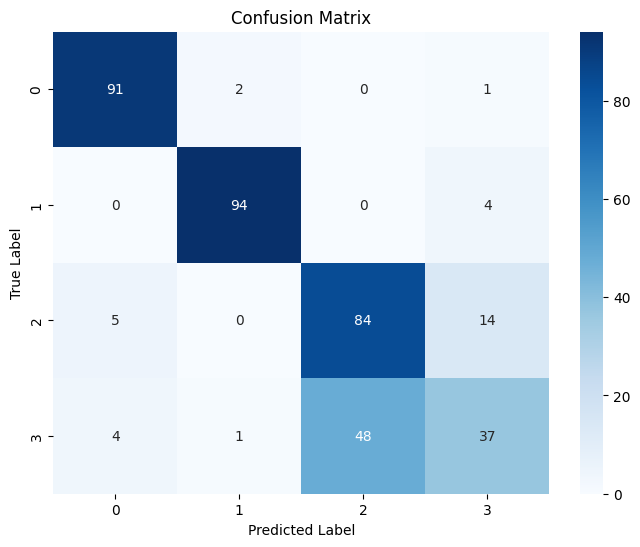

In [21]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [22]:
print(classification_report(y_test, y_pred, target_names=[f'Class {i}' for i in range(num_classes)]))

              precision    recall  f1-score   support

     Class 0       0.91      0.97      0.94        94
     Class 1       0.97      0.96      0.96        98
     Class 2       0.64      0.82      0.71       103
     Class 3       0.66      0.41      0.51        90

    accuracy                           0.79       385
   macro avg       0.79      0.79      0.78       385
weighted avg       0.79      0.79      0.78       385



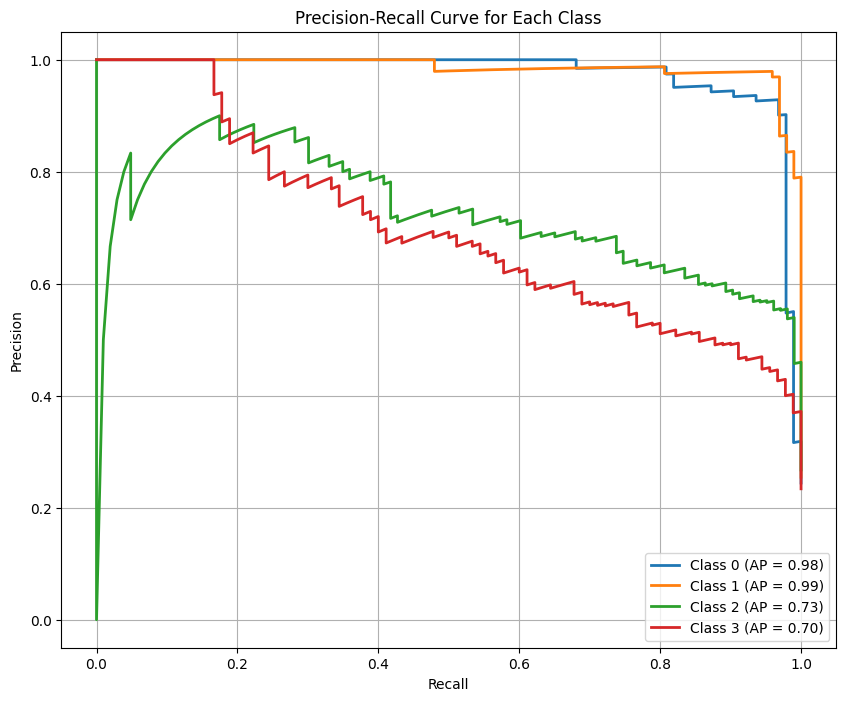

In [27]:
y_test_bin = label_binarize(y_test, classes=range(num_classes))

plt.figure(figsize=(10, 8))
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    avg_precision = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])
    plt.plot(recall, precision, lw=2, label=f'Class {i} (AP = {avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall')
plt.legend()
plt.grid()
plt.show()

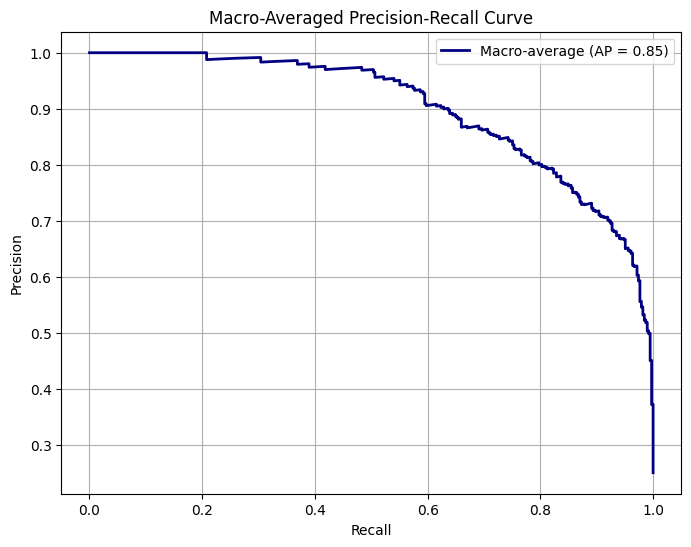

In [29]:
precision_macro, recall_macro, _ = precision_recall_curve(
    y_test_bin.ravel(), y_pred_proba.ravel()
)
avg_precision_macro = average_precision_score(y_test_bin, y_pred_proba, average='macro')

plt.figure(figsize=(8, 6))
plt.plot(recall_macro, precision_macro, lw=2,
         label=f'Macro-average (AP = {avg_precision_macro:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Macro-Averaged Precision-Recall')
plt.legend()
plt.grid()
plt.show()